# **IMAGE SUPER-RESOLUTION**

### **Prerequisite handling**

## **DF2K Dataset Preprocessing for Image Super Resolution (x2)**

In [1]:
#Change this to your dataset directory
BASE_DIR = r"D:\dataset"

In [2]:
#All reusable functions for pairing, scanning, cropping and saving images

def build_pairs(hr_dir, lr_dir):
    """Match each HR image with its corresponding LR image using the number in the filename."""
    hr_files = sorted(glob.glob(os.path.join(hr_dir, "*.png")))
    lr_files = sorted(glob.glob(os.path.join(lr_dir, "*.png")))

    lr_lookup = {}
    for lr_path in lr_files:
        match = re.match(r"(\d+)x\d+\.png", os.path.basename(lr_path))
        if match:
            lr_lookup[match.group(1)] = lr_path

    pairs = []
    for hr_path in hr_files:
        match = re.match(r"(\d+)\.png", os.path.basename(hr_path))
        if match and match.group(1) in lr_lookup:
            pairs.append((hr_path, lr_lookup[match.group(1)]))

    print(f"Found {len(pairs)} matched HR-LR pairs")
    return pairs


def scan_dimensions(pairs):
    """Go through every HR image, flip portrait ones to landscape, and record all dimensions."""
    min_h, min_w = float("inf"), float("inf")
    image_info = []

    for hr_path, lr_path in tqdm(pairs, desc="Scanning"):
        w, h = Image.open(hr_path).size
        is_portrait = h > w
        if is_portrait:
            h, w = w, h

        min_h = min(min_h, h)
        min_w = min(min_w, w)
        image_info.append({
            "hr_path": hr_path,
            "lr_path": lr_path,
            "is_portrait": is_portrait,
            "landscape_h": h,
            "landscape_w": w,
        })

    return min_h, min_w, image_info


def center_crop(img, target_w, target_h):
    """Crop the image from the center to the target size."""
    w, h = img.size
    left = (w - target_w) // 2
    top = (h - target_h) // 2
    return img.crop((left, top, left + target_w, top + target_h))


def process_and_save(image_info, crop_h, crop_w, out_hr_dir, out_lr_dir):
    """Rotate portraits to landscape, center crop both HR and LR, and save them."""
    os.makedirs(out_hr_dir, exist_ok=True)
    os.makedirs(out_lr_dir, exist_ok=True)

    lr_crop_h = crop_h // SCALE_FACTOR
    lr_crop_w = crop_w // SCALE_FACTOR
    skipped = 0

    for info in tqdm(image_info, desc="Processing"):
        hr_img = Image.open(info["hr_path"]).convert("RGB")
        lr_img = Image.open(info["lr_path"]).convert("RGB")

        if info["is_portrait"]:
            hr_img = hr_img.rotate(90, expand=True)
            lr_img = lr_img.rotate(90, expand=True)

        if hr_img.size[0] < crop_w or hr_img.size[1] < crop_h:
            skipped += 1
            continue

        center_crop(hr_img, crop_w, crop_h).save(
            os.path.join(out_hr_dir, os.path.basename(info["hr_path"]))
        )
        center_crop(lr_img, lr_crop_w, lr_crop_h).save(
            os.path.join(out_lr_dir, os.path.basename(info["lr_path"]))
        )

    print(f"Saved {len(image_info) - skipped}, skipped {skipped}")

### **Cropping method(Use any one method dont use both)**

In [ ]:
# Setting up libraries and all file paths for our dataset
import os
import glob
import re
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# Source paths
HR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_train_HR")
LR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_train_LR_bicubic", "X2")
VAL_HR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_valid_HR")
VAL_LR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_valid_LR_bicubic", "X2")

# Output paths
OUTPUT_HR_DIR = os.path.join(BASE_DIR, "DF2K_processed", "train", "HR")
OUTPUT_LR_DIR = os.path.join(BASE_DIR, "DF2K_processed", "train", "LR_X2")
OUTPUT_VAL_HR_DIR = os.path.join(BASE_DIR, "DF2K_processed", "valid", "HR")
OUTPUT_VAL_LR_DIR = os.path.join(BASE_DIR, "DF2K_processed", "valid", "LR_X2")

SCALE_FACTOR = 2

In [ ]:
# Find all HR-LR pairs and scan their dimensions for both train and validation sets
print("=== Training Set ===")
train_pairs = build_pairs(HR_DIR, LR_DIR)

print("\n=== Validation Set ===")
val_pairs = build_pairs(VAL_HR_DIR, VAL_LR_DIR)

print("\nScanning training images...")
train_min_h, train_min_w, train_info = scan_dimensions(train_pairs)

print("Scanning validation images...")
val_min_h, val_min_w, val_info = scan_dimensions(val_pairs)

min_h = min(train_min_h, val_min_h)
min_w = min(train_min_w, val_min_w)

print(f"\nGlobal min HR crop: {min_w} x {min_h}")
print(f"Global min LR crop: {min_w // SCALE_FACTOR} x {min_h // SCALE_FACTOR}")

In [ ]:
#Plot how image heights and widths are distributed so we can decide which small images to remove
all_info = train_info + val_info
heights = [info["landscape_h"] for info in all_info]
widths = [info["landscape_w"] for info in all_info]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(heights, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(min_h, color="red", linestyle="--", label=f"Min: {min_h}")
axes[0].set_title("Height Distribution (Landscape)")
axes[0].set_xlabel("Height (pixels)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(widths, bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(min_w, color="red", linestyle="--", label=f"Min: {min_w}")
axes[1].set_title("Width Distribution (Landscape)")
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Preview how many images we lose and how much we gain by removing small outliers
# Change H_THRESHOLD and W_THRESHOLD and re-run this cell to try different values
H_THRESHOLD = 1000
W_THRESHOLD = 1536

filtered = [info for info in all_info
            if info["landscape_h"] >= H_THRESHOLD and info["landscape_w"] >= W_THRESHOLD]

new_min_h = min(info["landscape_h"] for info in filtered)
new_min_w = min(info["landscape_w"] for info in filtered)

removed = len(all_info) - len(filtered)
old_pixels = min_h * min_w
new_pixels = new_min_h * new_min_w

removed_imgs = [info for info in all_info
                if info["landscape_h"] < H_THRESHOLD or info["landscape_w"] < W_THRESHOLD]

print(f"Images removed:   {removed} / {len(all_info)} ({removed/len(all_info)*100:.2f}%)")
print(f"Images remaining: {len(filtered)}")
print(f"Old crop size:    {min_w} x {min_h} = {old_pixels:,} pixels")
print(f"New crop size:    {new_min_w} x {new_min_h} = {new_pixels:,} pixels")
print(f"Pixel gain:       {(new_pixels/old_pixels - 1)*100:.1f}%")

In [ ]:
# Remove small outlier images, recalculate crop size, then crop and save everything
filtered_train = [info for info in train_info
                  if info["landscape_h"] >= H_THRESHOLD and info["landscape_w"] >= W_THRESHOLD]

filtered_val = [info for info in val_info
                if info["landscape_h"] >= H_THRESHOLD and info["landscape_w"] >= W_THRESHOLD]

all_filtered = filtered_train + filtered_val
new_min_h = min(info["landscape_h"] for info in all_filtered)
new_min_w = min(info["landscape_w"] for info in all_filtered)

print(f"Train: {len(train_info)} -> {len(filtered_train)}")
print(f"Valid: {len(val_info)} -> {len(filtered_val)}")
print(f"Crop size HR: {new_min_w} x {new_min_h}")
print(f"Crop size LR: {new_min_w // SCALE_FACTOR} x {new_min_h // SCALE_FACTOR}")

print("\n=== Processing Training Set ===")
process_and_save(filtered_train, new_min_h, new_min_w, OUTPUT_HR_DIR, OUTPUT_LR_DIR)

print("\n=== Processing Validation Set ===")
process_and_save(filtered_val, new_min_h, new_min_w, OUTPUT_VAL_HR_DIR, OUTPUT_VAL_LR_DIR)

In [ ]:
# Count saved files and display a sample pair to make sure everything looks correct
train_count = len(glob.glob(os.path.join(OUTPUT_HR_DIR, "*.png")))
val_count = len(glob.glob(os.path.join(OUTPUT_VAL_HR_DIR, "*.png")))

print(f"HR size: {new_min_w} x {new_min_h}")
print(f"LR size: {new_min_w // SCALE_FACTOR} x {new_min_h // SCALE_FACTOR}")
print(f"Training pairs:   {train_count}")
print(f"Validation pairs: {val_count}")

for name, hr_dir, lr_dir in [("Train", OUTPUT_HR_DIR, OUTPUT_LR_DIR),
                               ("Valid", OUTPUT_VAL_HR_DIR, OUTPUT_VAL_LR_DIR)]:
    sample_hr = sorted(glob.glob(os.path.join(hr_dir, "*.png")))[0]
    sample_lr = sorted(glob.glob(os.path.join(lr_dir, "*.png")))[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"{name} Sample", fontsize=14)
    axes[0].imshow(Image.open(sample_hr))
    axes[0].set_title(f"HR ({new_min_w}x{new_min_h})")
    axes[0].axis("off")
    axes[1].imshow(Image.open(sample_lr))
    axes[1].set_title(f"LR ({new_min_w // SCALE_FACTOR}x{new_min_h // SCALE_FACTOR})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

### **Patching Method (Alternative to Cropping)**

In [3]:
# Change BASE_DIR to wherever your DF2K dataset is stored
import os
import glob
import re
from PIL import Image
from tqdm import tqdm

HR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_train_HR")
LR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_train_LR_bicubic", "X2")
VAL_HR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_valid_HR")
VAL_LR_DIR = os.path.join(BASE_DIR, "DF2K", "DF2K_valid_LR_bicubic", "X2")

PATCH_TRAIN_HR_DIR = os.path.join(BASE_DIR, "DF2K_patches", "train", "HR")
PATCH_TRAIN_LR_DIR = os.path.join(BASE_DIR, "DF2K_patches", "train", "LR_X2")
PATCH_VAL_HR_DIR = os.path.join(BASE_DIR, "DF2K_patches", "valid", "HR")
PATCH_VAL_LR_DIR = os.path.join(BASE_DIR, "DF2K_patches", "valid", "LR_X2")

SCALE_FACTOR = 2
HR_PATCH_SIZE = 512
OVERLAP = 64
LR_PATCH_SIZE = HR_PATCH_SIZE // SCALE_FACTOR
LR_OVERLAP = OVERLAP // SCALE_FACTOR

print(f"HR patch: {HR_PATCH_SIZE}x{HR_PATCH_SIZE}, overlap: {OVERLAP}")
print(f"LR patch: {LR_PATCH_SIZE}x{LR_PATCH_SIZE}, overlap: {LR_OVERLAP}")

HR patch: 512x512, overlap: 64
LR patch: 256x256, overlap: 32


In [4]:
# Functions to match HR-LR pairs, extract patches from each image, and save them

def extract_patches(img, patch_size, overlap):
    """Slide a window across the image and extract all possible patches."""
    w, h = img.size
    stride = patch_size - overlap
    patches = []

    for top in range(0, h - patch_size + 1, stride):
        for left in range(0, w - patch_size + 1, stride):
            patch = img.crop((left, top, left + patch_size, top + patch_size))
            patches.append(patch)

    return patches


def tile_and_save(pairs, out_hr_dir, out_lr_dir):
    """For each HR-LR pair, extract all patches and save them as individual images."""
    os.makedirs(out_hr_dir, exist_ok=True)
    os.makedirs(out_lr_dir, exist_ok=True)

    patch_count = 0

    for hr_path, lr_path in tqdm(pairs, desc="Tiling"):
        hr_img = Image.open(hr_path).convert("RGB")
        lr_img = Image.open(lr_path).convert("RGB")

        hr_patches = extract_patches(hr_img, HR_PATCH_SIZE, OVERLAP)
        lr_patches = extract_patches(lr_img, LR_PATCH_SIZE, LR_OVERLAP)

        assert len(hr_patches) == len(lr_patches), \
            f"Patch mismatch for {os.path.basename(hr_path)}: {len(hr_patches)} HR vs {len(lr_patches)} LR"

        base_name = os.path.splitext(os.path.basename(hr_path))[0]

        for i, (hr_patch, lr_patch) in enumerate(zip(hr_patches, lr_patches)):
            hr_patch.save(os.path.join(out_hr_dir, f"{base_name}_p{i:04d}.png"))
            lr_patch.save(os.path.join(out_lr_dir, f"{base_name}_p{i:04d}.png"))
            patch_count += 1

    return patch_count

In [5]:
# Match HR-LR pairs and tile both train and validation sets into patches
print("=== Training Set ===")
train_pairs = build_pairs(HR_DIR, LR_DIR)

print("\n=== Validation Set ===")
val_pairs = build_pairs(VAL_HR_DIR, VAL_LR_DIR)

print("\n=== Tiling Training Set ===")
train_patch_count = tile_and_save(train_pairs, PATCH_TRAIN_HR_DIR, PATCH_TRAIN_LR_DIR)
print(f"Total training patches: {train_patch_count}")

print("\n=== Tiling Validation Set ===")
val_patch_count = tile_and_save(val_pairs, PATCH_VAL_HR_DIR, PATCH_VAL_LR_DIR)
print(f"Total validation patches: {val_patch_count}")

=== Training Set ===
Found 3450 matched HR-LR pairs

=== Validation Set ===
Found 100 matched HR-LR pairs

=== Tiling Training Set ===


Tiling: 100%|██████████████████████████████████████████████████████████████████████| 3450/3450 [23:32<00:00,  2.44it/s]


Total training patches: 30713

=== Tiling Validation Set ===


Tiling: 100%|████████████████████████████████████████████████████████████████████████| 100/100 [00:37<00:00,  2.64it/s]

Total validation patches: 900


In [6]:
# Show how many patches we got from the original images
print(f"{'='*50}")
print(f"PATCH SUMMARY")
print(f"{'='*50}")
print(f"HR patch size:      {HR_PATCH_SIZE}x{HR_PATCH_SIZE}")
print(f"LR patch size:      {LR_PATCH_SIZE}x{LR_PATCH_SIZE}")
print(f"Overlap:            {OVERLAP}px")
print(f"Training patches:   {train_patch_count}  (from {len(train_pairs)} images)")
print(f"Validation patches: {val_patch_count}  (from {len(val_pairs)} images)")
print(f"Data multiplier:    ~{train_patch_count / len(train_pairs):.1f}x per image")
print(f"{'='*50}")

PATCH SUMMARY
HR patch size:      512x512
LR patch size:      256x256
Overlap:            64px
Training patches:   30713  (from 3450 images)
Validation patches: 900  (from 100 images)
Data multiplier:    ~8.9x per image


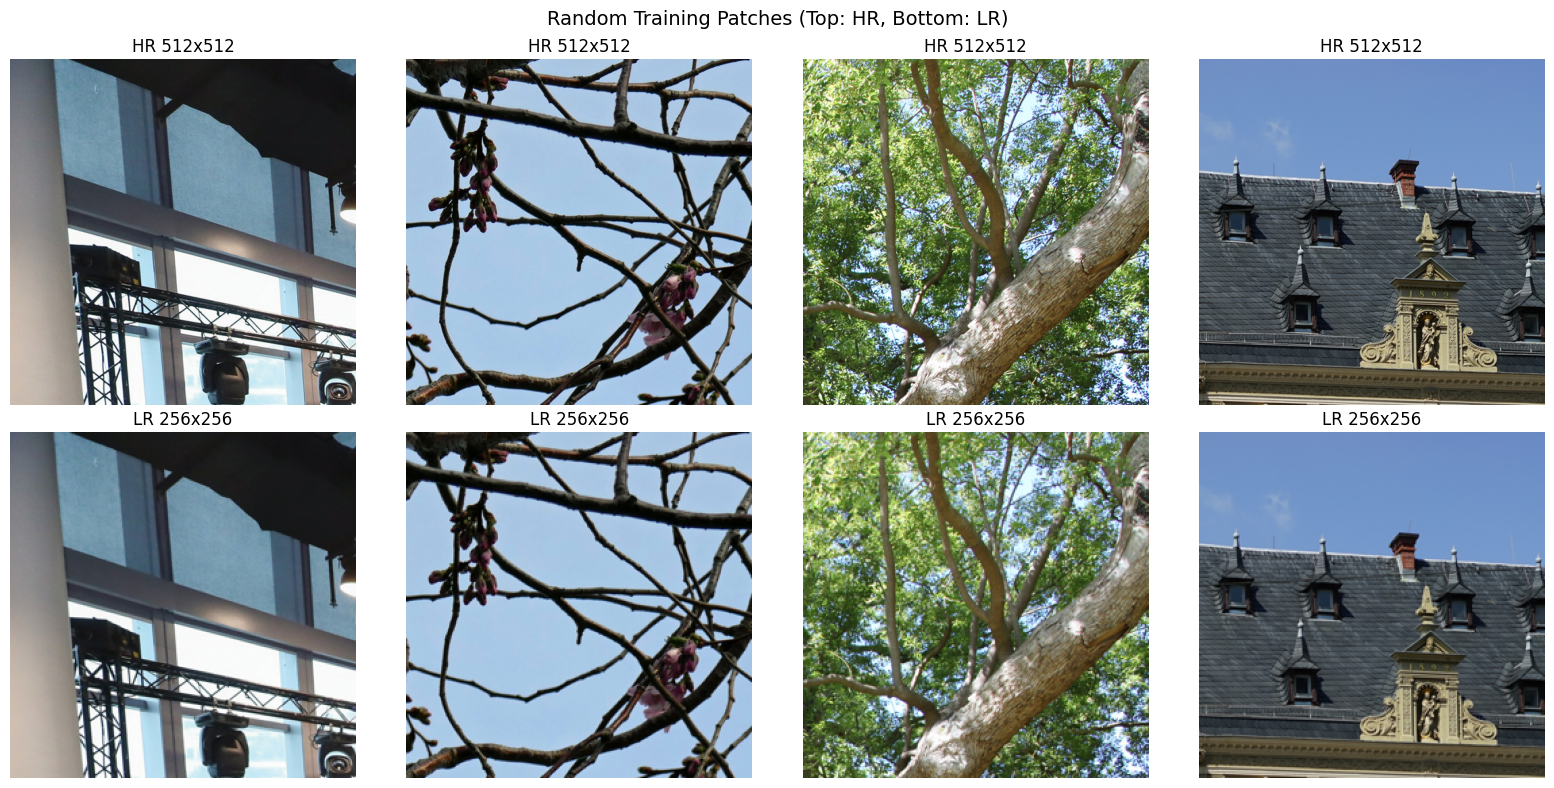

In [7]:
# Display a few random patches to verify they look correct
import matplotlib.pyplot as plt
import random

hr_patches = sorted(glob.glob(os.path.join(PATCH_TRAIN_HR_DIR, "*.png")))
lr_patches = sorted(glob.glob(os.path.join(PATCH_TRAIN_LR_DIR, "*.png")))

samples = random.sample(range(len(hr_patches)), 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Random Training Patches (Top: HR, Bottom: LR)", fontsize=14)

for col, idx in enumerate(samples):
    axes[0, col].imshow(Image.open(hr_patches[idx]))
    axes[0, col].set_title(f"HR {HR_PATCH_SIZE}x{HR_PATCH_SIZE}")
    axes[0, col].axis("off")

    axes[1, col].imshow(Image.open(lr_patches[idx]))
    axes[1, col].set_title(f"LR {LR_PATCH_SIZE}x{LR_PATCH_SIZE}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## **DATA LOADER FOR CROPPED DATASET**

In [10]:
# Load images and randomly crop a small patch each time — fast and memory friendly
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random

class SRDatasetRandomCrop(Dataset):
    def __init__(self, hr_dir, lr_dir, hr_crop_size=256):
        self.hr_files = sorted(glob.glob(os.path.join(hr_dir, "*.png")))
        self.lr_files = sorted(glob.glob(os.path.join(lr_dir, "*.png")))
        assert len(self.hr_files) == len(self.lr_files), \
            f"Mismatch: {len(self.hr_files)} HR vs {len(self.lr_files)} LR"
        self.hr_crop_size = hr_crop_size
        self.lr_crop_size = hr_crop_size // SCALE_FACTOR
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.hr_files)

    def __getitem__(self, idx):
        hr = Image.open(self.hr_files[idx]).convert("RGB")
        lr = Image.open(self.lr_files[idx]).convert("RGB")

        # Pick random position on LR first, then scale up for HR to ensure alignment
        lr_w, lr_h = lr.size
        lr_top = random.randint(0, lr_h - self.lr_crop_size)
        lr_left = random.randint(0, lr_w - self.lr_crop_size)

        hr_top = lr_top * SCALE_FACTOR
        hr_left = lr_left * SCALE_FACTOR

        lr = lr.crop((lr_left, lr_top, lr_left + self.lr_crop_size, lr_top + self.lr_crop_size))
        hr = hr.crop((hr_left, hr_top, hr_left + self.hr_crop_size, hr_top + self.hr_crop_size))

        return self.to_tensor(lr), self.to_tensor(hr)


train_dataset = SRDatasetRandomCrop(
    hr_dir=os.path.join(BASE_DIR, "DF2K_processed", "train", "HR"),
    lr_dir=os.path.join(BASE_DIR, "DF2K_processed", "train", "LR_X2"),
    hr_crop_size=256
)

val_dataset = SRDatasetRandomCrop(
    hr_dir=os.path.join(BASE_DIR, "DF2K_processed", "valid", "HR"),
    lr_dir=os.path.join(BASE_DIR, "DF2K_processed", "valid", "LR_X2"),
    hr_crop_size=256
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"Valid: {len(val_dataset)} images, {len(val_loader)} batches")

Train: 3429 images, 215 batches
Valid: 99 images, 13 batches
